In [101]:
%pip install numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [102]:
df_repro = pd.read_csv('reproduction/speaker-verification.csv')
df_paper = pd.read_csv('paper/speaker-verification.csv')
df_repro

,run_id,run_name,dataset,architecture,train_strategy,test_strategy,eer_mean,eer_std
0,5ecaecvs,CNN-timit-OS/final,timit,CNN,OS,OS,5.221478,0.082623
1,5ecaecvs,CNN-timit-OS/final,timit,CNN,OS,SS,11.221982,0.870683
2,5ecaecvs,CNN-timit-OS/final,timit,CNN,OS,SU,11.357626,0.650520
3,b7mqjubc,CNN-timit-SS/final,timit,CNN,SS,OS,7.828465,0.358819
4,b7mqjubc,CNN-timit-SS/final,timit,CNN,SS,SS,5.293670,0.167192
5,b7mqjubc,CNN-timit-SS/final,timit,CNN,SS,SU,5.192398,0.182284
6,p0o3v8w8,Conformer-timit-OS/final,timit,Conformer,OS,OS,2.381912,0.071319
7,p0o3v8w8,Conformer-timit-OS/final,timit,Conformer,OS,SS,6.955571,0.620567
8,p0o3v8w8,Conformer-timit-OS/final,timit,Conformer,OS,SU,8.055562,0.688553
9,wpoh7dv7,Conformer-timit-SS/final,timit,Conformer,SS,OS,3.217527,0.148393


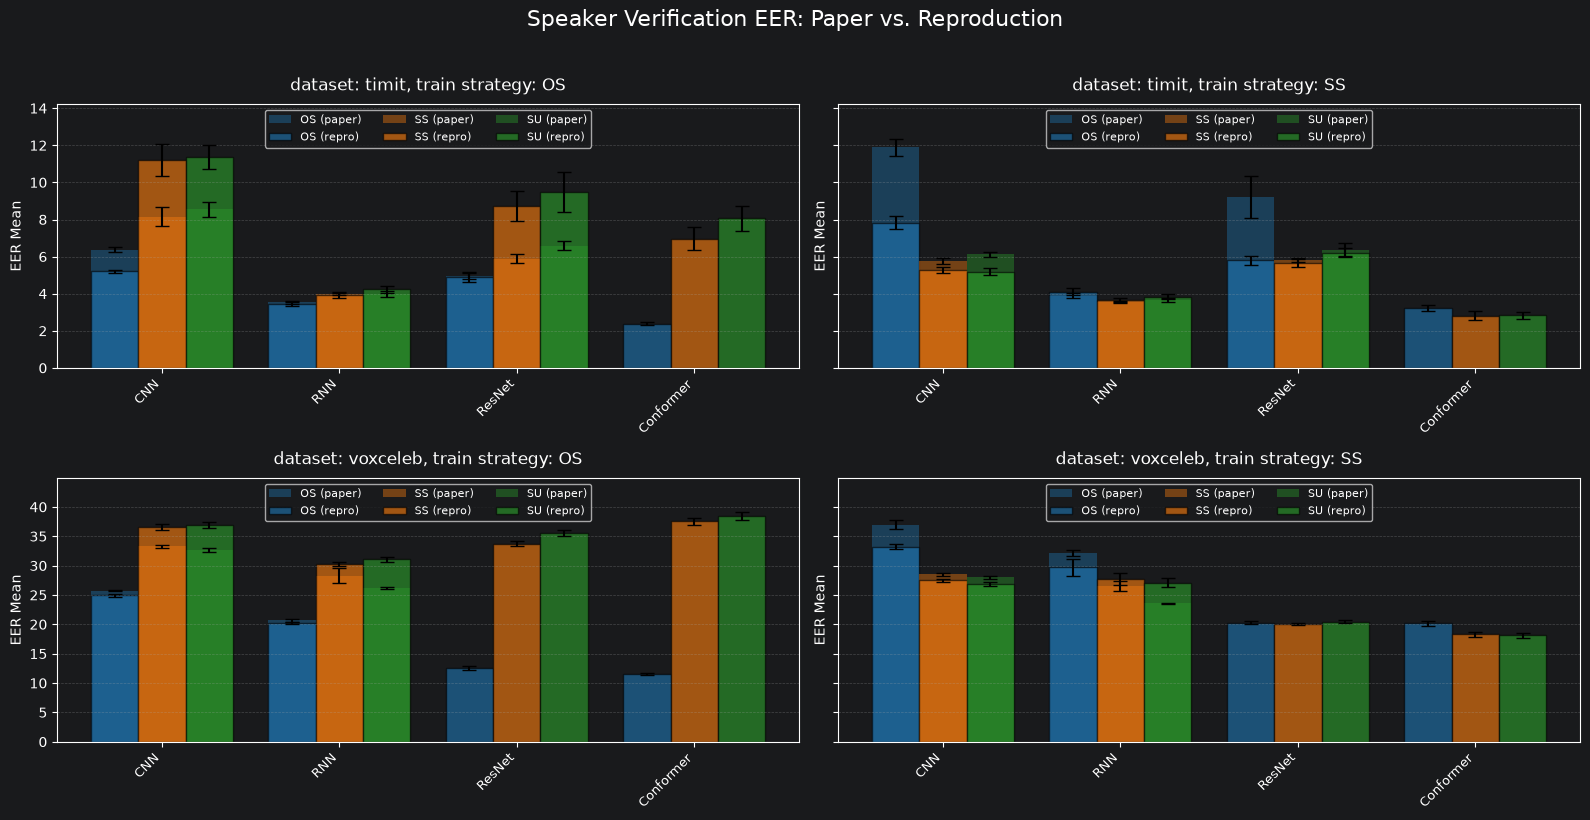

In [103]:
# Filter for OS and SS training strategies only
df_filtered_repro = df_repro[df_repro['train_strategy'].isin(['OS', 'SS'])].copy()
df_filtered_paper = df_paper[df_paper['train_strategy'].isin(['OS', 'SS'])].copy()

# Define fixed architecture order
architectures = ['CNN', 'RNN', 'ResNet', 'Conformer']

# Get unique datasets and training strategies
datasets = sorted(df_filtered_repro['dataset'].unique())
train_strategies = sorted(df_filtered_repro['train_strategy'].unique())
test_strategies = sorted(df_filtered_repro['test_strategy'].unique())

# Set up the 2x2 grid: rows=datasets, cols=training_strategies
fig, axes = plt.subplots(len(datasets), len(train_strategies),
                         figsize=(16, 8), sharey='row')

# If only one row or column, axes will be 1D, so we need to handle that
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
if len(train_strategies) == 1:
    axes = axes.reshape(-1, 1)

# Define colors for test strategies
colors = {'OS': '#1f77b4', 'SS': '#ff7f0e', 'SU': '#2ca02c'}
labels = {'OS': 'OS (repro)', 'SS': 'SS (repro)', 'SU': 'SU (repro)'}

# Find global max for y-axis alignment (from both repro and paper)
# Calculate max per dataset for y-axis alignment
dataset_max = {}
for dataset in datasets:
    dataset_data_repro = df_filtered_repro[df_filtered_repro['dataset'] == dataset]
    dataset_data_paper = df_filtered_paper[df_filtered_paper['dataset'] == dataset]
    eer_max_repro = dataset_data_repro['eer_mean'] + dataset_data_repro['eer_std']
    eer_max_paper = dataset_data_paper['eer_mean'] + dataset_data_paper['eer_std']
    all_eer_max = pd.concat([eer_max_repro, eer_max_paper])
    dataset_max[dataset] = max(all_eer_max) * 1.15

# Determine bar width based on number of test strategies
n_test = len(test_strategies)
bar_width = 0.8 / n_test

# Plot for each dataset and training strategy
for i, dataset in enumerate(datasets):
    for j, train_strategy in enumerate(train_strategies):
        ax = axes[i, j]
        
        # Get data (repro)
        subset_repro = df_filtered_repro[(df_filtered_repro['dataset'] == dataset) &
                              (df_filtered_repro['train_strategy'] == train_strategy)]
        
        # Get data (paper)
        subset_paper = df_filtered_paper[(df_filtered_paper['dataset'] == dataset) &
                              (df_filtered_paper['train_strategy'] == train_strategy)]
        
        # Get architectures (preserving order)
        subset_architectures = [arch for arch in architectures if arch in subset_repro['architecture'].unique()]
        
        if not subset_architectures:
            ax.set_title(f'{dataset}, Train: {train_strategy}', fontsize=12, pad=10)
            continue
        
        n_arch = len(subset_architectures)
        x = np.arange(n_arch)
        
        # Plot each test strategy
        for k, test_strategy in enumerate(test_strategies):
            offset = (k - (n_test - 1) / 2) * bar_width
            
            # Paper shadow bars
            paper_arch_to_eer = {}
            paper_arch_to_std = {}
            if len(subset_paper) > 0:
                test_data_paper = subset_paper[subset_paper['test_strategy'] == test_strategy]
                for _, row in test_data_paper.iterrows():
                    paper_arch_to_eer[row['architecture']] = row['eer_mean']
                    paper_arch_to_std[row['architecture']] = row['eer_std']
            
            paper_means = [paper_arch_to_eer.get(arch, None) for arch in subset_architectures]
            paper_stds = [paper_arch_to_std.get(arch, None) for arch in subset_architectures]
            
            paper_x, paper_means_filt, paper_stds_filt = [], [], []
            for idx, (mean, std) in enumerate(zip(paper_means, paper_stds)):
                if mean is not None:
                    paper_x.append(x[idx] + offset)
                    paper_means_filt.append(mean)
                    paper_stds_filt.append(std)
            
            if len(paper_x) > 0:
                ax.bar(paper_x, paper_means_filt, bar_width,
                       yerr=paper_stds_filt, capsize=5,
                       color=colors[test_strategy],
                       alpha=0.4, edgecolor='none',
                       label=f'{test_strategy} (paper)')
            
            # Repro solid bars
            test_data_repro = subset_repro[subset_repro['test_strategy'] == test_strategy]
            arch_to_eer = {}
            arch_to_std = {}
            for _, row in test_data_repro.iterrows():
                arch_to_eer[row['architecture']] = row['eer_mean']
                arch_to_std[row['architecture']] = row['eer_std']
            
            eer_means = [arch_to_eer.get(arch, 0) for arch in subset_architectures]
            eer_stds = [arch_to_std.get(arch, 0) for arch in subset_architectures]
            
            ax.bar(x + offset, eer_means, bar_width,
                   yerr=eer_stds, capsize=5,
                   color=colors[test_strategy],
                   alpha=0.6, edgecolor='black',
                   label=labels[test_strategy])
        
        # Customize plot
        ax.set_title(f'dataset: {dataset}, train strategy: {train_strategy}', fontsize=12, pad=10)
        ax.set_ylabel('EER Mean', fontsize=10)
        ax.set_ylim(0, dataset_max[dataset])
        ax.set_xticks(x)
        ax.set_xticklabels(subset_architectures, rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.legend(loc='upper center', fontsize=8, ncol=3)

plt.suptitle('Speaker Verification EER: Paper vs. Reproduction', fontsize=16, y=1.02)
plt.tight_layout()

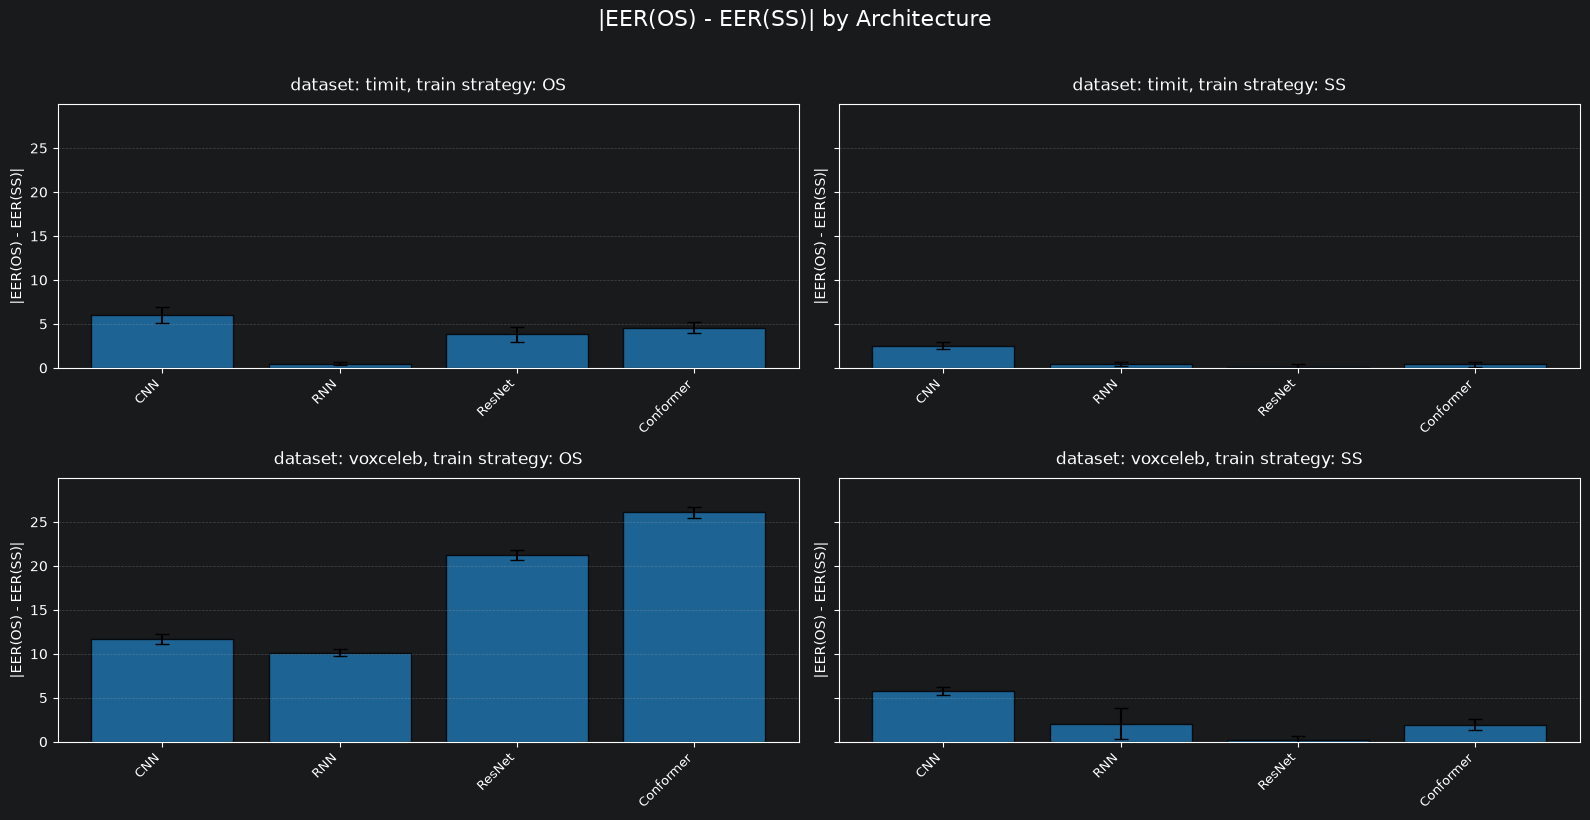

In [104]:
# Plot absolute difference between test_strategy OS and SS
# Filter for OS and SS training strategies only
df_filtered = df_repro[df_repro['train_strategy'].isin(['OS', 'SS'])].copy()

# Define fixed architecture order
architectures = ['CNN', 'RNN', 'ResNet', 'Conformer']

# Get unique datasets and training strategies
datasets = sorted(df_filtered['dataset'].unique())
train_strategies = sorted(df_filtered['train_strategy'].unique())

# Calculate all absolute differences first (for global max)
all_diffs = []
for dataset in datasets:
    for train_strategy in train_strategies:
        subset = df_filtered[(df_filtered['dataset'] == dataset) &
                            (df_filtered['train_strategy'] == train_strategy)]
        os_data = subset[subset['test_strategy'] == 'OS']
        ss_data = subset[subset['test_strategy'] == 'SS']
        for arch in architectures:
            os_eer = os_data[os_data['architecture'] == arch]['eer_mean'].values
            ss_eer = ss_data[ss_data['architecture'] == arch]['eer_mean'].values
            if len(os_eer) > 0 and len(ss_eer) > 0:
                all_diffs.append(abs(os_eer[0] - ss_eer[0]))

# Calculate global max for y-axis alignment
global_max = max(all_diffs) * 1.15 if all_diffs else 1.0

# Set up the 2x2 grid: rows=datasets, cols=training_strategies
fig, axes = plt.subplots(len(datasets), len(train_strategies),
                         figsize=(16, 8), sharey=True)

# Handle single row/column cases
if len(datasets) == 1:
    axes = axes.reshape(1, -1)
if len(train_strategies) == 1:
    axes = axes.reshape(-1, 1)

# Create bar charts
for i, dataset in enumerate(datasets):
    for j, train_strategy in enumerate(train_strategies):
        ax = axes[i, j]
        
        # Get data for this dataset and training_strategy
        subset = df_filtered[(df_filtered['dataset'] == dataset) &
                            (df_filtered['train_strategy'] == train_strategy)]
        
        # Get OS and SS test strategy data
        os_data = subset[subset['test_strategy'] == 'OS']
        ss_data = subset[subset['test_strategy'] == 'SS']
        
        # Calculate absolute differences for each architecture
        subset_architectures = [arch for arch in architectures if arch in subset['architecture'].unique()]
        differences = []
        errors = []
        for arch in subset_architectures:
            os_row = os_data[os_data['architecture'] == arch].iloc[0]
            ss_row = ss_data[ss_data['architecture'] == arch].iloc[0]

            diff = abs(os_row['eer_mean'] - ss_row['eer_mean'])
            std_diff = (os_row['eer_std']**2 + ss_row['eer_std']**2)**0.5

            differences.append(diff)
            errors.append(std_diff)
        
        # Set up x positions
        n_arch = len(subset_architectures)
        x = np.arange(n_arch)
        
        # Plot bars for absolute differences
        ax.bar(x, differences, yerr=errors, capsize=5, color='#1f77b4', alpha=0.8, edgecolor='black')
        
        # Customize the plot
        ax.set_title(f'dataset: {dataset}, train strategy: {train_strategy}', fontsize=12, pad=10)
        ax.set_ylabel('|EER(OS) - EER(SS)|', fontsize=10)
        ax.set_ylim(0, global_max)
        ax.set_xticks(x)
        ax.set_xticklabels(subset_architectures, rotation=45, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add overall title and adjust layout
plt.suptitle('|EER(OS) - EER(SS)| by Architecture', fontsize=16, y=1.02)
plt.tight_layout()